### Домашнее задание 6

Это домашнее задание посвящено устойчивости и попыткам стабилизировать разные системы.

**Задача 1**

Проанализируйте линейные автономные непрерывные системы с точки зрения устойчивости с использованием критерия $\text{Re} \lambda_i < 0$.

Ответьте на вопросы: является ли система устойчивой? Является ли она асимптотически устойчивой?

$\dot{x} = \begin{pmatrix}
\dot{p} \\
\ddot{p}
\end{pmatrix}$
$ = A x$

1) $A =  \begin{pmatrix}
0 & 1 \\
0 & 0
\end{pmatrix}$

2) $A = \begin{pmatrix}
0 & 1 \\
-0.3 & 0
\end{pmatrix}$

3) $A = \begin{pmatrix}
1 & 2 \\
-3 & -4
\end{pmatrix}$


**Решение**

In [1]:
import numpy as np

matrices = dict(
    A1=np.array([[0, 1], [0, 0]], dtype=np.float32),
    A2=np.array([[0, 1], [-0.3, 0]], dtype=np.float32),
    A3=np.array([[1, 2], [-3, -4]], dtype=np.float32),
)

for name, matrix in matrices.items():
    real_eig = np.real(np.linalg.eigvals(matrix))
    is_stable = np.all(real_eig <= 0)
    is_asymptotically_stable = np.all(real_eig < 0)

    print(f"system {name}  is_stable: {is_stable}  is_asymptotically_stable: {is_asymptotically_stable}")

system A1  is_stable: True  is_asymptotically_stable: False
system A2  is_stable: True  is_asymptotically_stable: False
system A3  is_stable: True  is_asymptotically_stable: True


---


**Задача 2**

Проанализируйте линейную дискретную систему, описывающую поведение пружинного маятника с грузом массы $m$ и жесткостью $k$, полученную путем дискретизации ($\Delta t$ известно) системы непрерывных уравнений. Найдите собственные значения матрицы системы. Является ли непрерывная система устойчивой? А дискретная? Добавьте в систему вязкое трение. Стала ли непрерывная система асимптотически устойчивой? Стала ли дискретная система устойчивой? А асимптотически устойчивой?


**Решение**

Система:

$ x = \begin{bmatrix} p \\ \dot{p} \end{bmatrix}, \quad \dot{x} = Ax, \quad A = \begin{bmatrix} 0 & 1 \\ -\frac{k}{m} & 0 \end{bmatrix} $

In [2]:
import sympy as sp
k, m = sp.symbols("k,m")
A = sp.Matrix([[0, 1], [-k/m, 0]])
eigvals = list(A.eigenvals().keys())
print(f"Eigenvalues of continious system: {eigvals}")

Eigenvalues of continious system: [-sqrt(-k/m), sqrt(-k/m)]


Собственные значения непрерывной системы:

$\lambda_1 = 0 - i\sqrt{\frac{k}{m}}, \quad \lambda_2 = 0 + i\sqrt{\frac{k}{m}}$

Значит, система устойчива, но не асимптотически

Дискретная система:

$x_{t+1} = (I + \Delta t A) x_t = \tilde{A} x_t, \quad \tilde{A} = \begin{bmatrix} 1 & \Delta t \\ -\Delta t \frac{k}{m} & 1 \end{bmatrix}$


In [3]:
dt = sp.Symbol(r"\Delta t")
A = sp.Matrix([[1, dt], [-dt * k / m, 1]])
eigvals = list(A.eigenvals().keys())
print(f"Eigenvalues of discrete system: {eigvals}")

Eigenvalues of discrete system: [-\Delta t*sqrt(-k*m)/m + 1, \Delta t*sqrt(-k*m)/m + 1]


Собственные значения дискретной системы:

$\lambda_1 = 1 - i \Delta t \sqrt{\frac{k}{m}}, \quad \lambda_2 = 1 + i \Delta t \sqrt{\frac{k}{m}}$

Значит, система устойчива, но не асимптотически

---


**Задача 3**

Научитесь генерировать случайные системы $2 \times 2$ (где каждый элемент матрицы - это случайное число из нормального распределения). Проанализируйте эти системы, попытавшись найти такую матрицу $M$, что $A^T M + M A \prec 0$ (найдите для этого программное средство). Какая доля случайных систем оказалась устойчивой? Какая будет доля для $3 \times 3$ и $4 \times 4$?


In [4]:
from typing import Tuple
import cvxpy as cp

EPS = 1e-9

shapes = [(2, 2), (3, 3), (4, 4)]


def is_stable(A: np.ndarray):
    assert A.ndim == 2
    assert A.shape[0] == A.shape[1]
    n = A.shape[0]

    M = cp.Variable(shape=(n, n), symmetric=True)

    problem = cp.Problem(cp.Minimize(0), constraints=[A.T @ M + M @ A << -EPS, M >> 0])
    problem.solve()

    return problem.status not in [cp.INFEASIBLE, cp.INFEASIBLE_INACCURATE]


def get_fraction_stable_systems(shape: Tuple[int, int], num_trials: int = 1000):
    return np.mean([1 if is_stable(np.random.normal(size=shape)) else 0 for _ in range(num_trials)])


for shape in shapes:
    feasible_frac = get_fraction_stable_systems(shape)
    print(f"shape {shape}  fraction of stable systems: {feasible_frac:.4f}")

shape (2, 2)  fraction of stable systems: 1.0000
shape (3, 3)  fraction of stable systems: 1.0000
shape (4, 4)  fraction of stable systems: 1.0000


---


**Задача 4**

Реализуйте решение уравнения Ляпунова (поиск такой матрицы $M$, что $A^T M + M A = -Q$, где $Q$ положительно определена). Возможный вариант решения следующий:
- использовать разложение Шура для матрицы $A$
- упростить уравнение Ляпунова
- решить его "по частям" методом обратной подстановки


**Решение**

Примерим разложение Шура к $A$: \
$A = UTU^\top, \quad U \text{ - ортонормальная,} \quad T \text{ - верхняя треугольная}$

Подставим в уравнение: \
$U T^\top U^\top M + M U T U^\top = -Q \quad \mid \quad U^\top \cdot \ldots \cdot U$ \
$T^\top U^\top M U + U^\top M U T = - U^\top Q U \quad \mid \quad \tilde{M} = U^\top M U, \tilde{Q} = U^\top Q U$ \
$T^\top \tilde{M} + \tilde{M} T = -\tilde{Q}$

Рассмотрим его блочный вариант: \
$\begin{bmatrix} T_{11}^\top & 0 \\ T_{12}^\top & T_{22}^\top \end{bmatrix} \begin{bmatrix} \tilde{M}_{11} & \tilde{M}_{12} \\ \tilde{M}_{21} & \tilde{M}_{22} \end{bmatrix} + \begin{bmatrix} \tilde{M}_{11} & \tilde{M}_{12} \\ \tilde{M}_{21} & \tilde{M}_{22} \end{bmatrix} \begin{bmatrix} T_{11} & T_{12} \\ 0 & T_{22} \end{bmatrix} = - \begin{bmatrix} \tilde{Q}_{11} & \tilde{Q}_{12} \\ \tilde{Q}_{21} & \tilde{Q}_{22} \end{bmatrix}$

Мы можем решить это по частям. Сначала находим $\tilde{M}_{11}$: \
$T_{11}^\top \tilde{M}_{11} + \tilde{M}_{11} T_{11} = - \tilde{Q}_{11}$

Далее подставляем готовый результат в следующую линейную систему, и так на каждом шаге: \
$T_{11}^\top \tilde{M}_{12} + \tilde{M}_{12} T_{22} = -\tilde{Q}_{12} - \tilde{M}_{11} T_{12} \\
T_{22}^\top \tilde{M}_{21} + \tilde{M}_{21} T_{11} = -\tilde{Q}_{21} - T_{12}^\top \tilde{M}_{11} \\
T_{22}^\top \tilde{M}_{22} + \tilde{M}_{22} T_{22} = -\tilde{Q}_{22} - T_{12}^\top \tilde{M}_{12} - \tilde{M}_{21} T_{12}$

In [5]:
from scipy.linalg import schur, solve_continuous_lyapunov

def solve_lyapunov(A: np.ndarray, Q: np.ndarray):
    assert np.all(np.linalg.eigvals(Q) > 0)
    T, U = schur(A, output="real")
    Q_tilda = U.T @ Q @ U
    M_tilda = solve_continuous_lyapunov(T.T, -Q_tilda)

    return U @ M_tilda @ U.T

n = 3
A = np.random.normal(size=(n, n))
Q = np.eye(n)
M = solve_lyapunov(A, Q)

print(f"matrix M:\n{M}")

assert np.linalg.norm(A.T @ M + M @ A + Q, ord="fro") < EPS

matrix M:
[[ 1.59027577 -2.12979463 -1.3523979 ]
 [-2.12979463  4.86325639  3.03421262]
 [-1.3523979   3.03421262  5.83643672]]


---


**Задача 5**

Если для системы $\dot{x} = A x + B u$ найти обратную связь в форме $u = - K x$, то уравнение системы преобразуется к виду $\dot{x} = (A - B K) x$. Это означает, что обеспечение устойчивости такой системы сводится к нахождению такой матрицы $K$, что $\text{Re} (\sigma(A - BK)) < 0$ ($\sigma$ - спектр оператора, набор его собственных чисел). Используйте метод pole placement https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.place_poles.html для поиска стабилизирующего управления для какой-нибудь линейной системы, которая не устойчива без управления.


In [ ]:
from scipy.signal import place_poles

A = np.array([[0, 1], [1, 0]], dtype=np.float32)
eigvals = np.linalg.eigvals(A)
print(f"eigenvalues of unstable system matrix A:\n{np.real(eigvals)}")
assert np.any(np.real(eigvals) > 0)

B = np.array([[0], [1]], dtype=np.float32)

desired_poles = np.array([-1, -2], dtype=np.float32)

K = place_poles(A, B, desired_poles).gain_matrix

print(f"grain matrix K:\n{K}")

eigvals = np.linalg.eigvals(A - B @ K)
assert np.all(np.real(eigvals) < 0)



eigenvalues of unstalbe system matrix A:
[ 1. -1.]
grain matrix K:
[[3. 3.]]


---


**Задача 6**

Проанализируйте устойчивость системы по Ляпунову: $\dot{x} = -x^3$. Нужно найти функцию Ляпунова, проверив все необходимые свойства.


**Решение**

Функция Ляпунова: $V(x) = \frac{x^2}{2}$.
Проверим все необходимые свойства функции Ляпунова:

1. $V(x)$ - непрерывная на всей области определения
2. Единственный корень: $x = 0$, для остальных $x$ $V(x) > 0$
3. $V(x)$ радиально неограниченная
4. $\frac{dV(x)}{dt} = x \dot{x} = -x^4 < 0$ для $x \neq 0$

---


**Задача 7**

Реализуйте energy-based control в применении к стабилизации обратного маятника (как в прошлой домашке). Реализуйте переключение на стабилизирующее управление в небольшой окрестности целевого положения. Визуализируйте управление как поверхность, как векторное поле, сравните с другими контроллерами, которые вы реализовывали. Найдите время стабилизации для разных начальных условий (тепловую карту). Есть ли начальные условия, при которых этот контроллер работает медленнее, чем основанный на эвристиках?


**Решение**

Будем использовать функцию Ляпунова с семинара: \
$V(\theta, \dot{\theta}) = \frac{(E(\theta, \dot{\theta}) - E(0, 0))^2}{2}$ \
где \
$E(\theta, \dot{\theta}) = \frac{ml^2\dot{\theta}^2}{2} + mgl\cos\theta$

Вычислим производную:
$\frac{dV(x)}{dt} = (E(\theta, \dot{\theta}) - E(0, 0)) (ml^2\dot{\theta}\ddot{\theta} - mgl\sin\theta)$ \
Подставим $\ddot{\theta} = \frac{g}{l}\sin\theta + \frac{u}{ml^2}$: \
$\frac{dV(x)}{dt} = (E(\theta, \dot{\theta}) - E(0, 0)) \dot{\theta} u$

Для того, чтобы выполнялось условие $\frac{dV(x)}{dt} < 0$ для всех $\theta \neq 0$ необходимо и достаточно, чтобы $\text{sign}(u) = -\text{sign} \left( (E(\theta, \dot{\theta}) - E(0, 0)) \dot{\theta} \right)$

In [61]:
from typing import Callable, Optional
import numpy as np
import cv2
from functools import partial


def inverted_pendulum_dynamics(x: np.ndarray, u: float, l: float, m: float, g: float, tau_max: float) -> np.ndarray:
    p, p_dot = x
    p_ddot = g / l * np.sin(p) + np.clip(u, -tau_max, tau_max) / m / l**2
    return np.array([p_dot, p_ddot])


class InvertedPendulumSimulator:
    def __init__(self, l: float = 1.0, m: float = 1.0, g: float = 9.81, dt: float = 0.01, tau_max: float = 3.0):
        self.l = l
        self.m = m
        self.g = g
        self.dt = dt
        self.tau_max = abs(tau_max)

        self.dynamics_fn = partial(inverted_pendulum_dynamics, l=l, m=m, g=g, tau_max=tau_max)

        self.width = 700
        self.height = 700

    def reset(self, x: Optional[np.ndarray] = None) -> np.ndarray:
        if x is None:
            x = np.array([3.0, 0])
        self.x = x
        self.t = 0.0

        return self.x

    def step(self, u: float) -> np.ndarray:
        x_dot = self.dynamics_fn(self.x, u)

        self.x += x_dot * self.dt
        self.t += self.dt

        return self.x

    def render(self) -> np.ndarray:
        canvas = np.full(shape=(self.height, self.width, 3), fill_value=255, dtype=np.uint8)
        scale = (min(self.width, self.height) * 0.375) / self.l

        pivot_x, pivot_y = self.width // 2, self.height // 2

        p, p_dot = self.x
        pendulum_x = int(pivot_x + scale * self.l * np.sin(p))
        pendulum_y = int(pivot_y - scale * self.l * np.cos(p))

        cv2.line(canvas, (pivot_x, pivot_y), (pendulum_x, pendulum_y), (0, 0, 0), 3, cv2.LINE_AA)
        cv2.circle(canvas, (pivot_x, pivot_y), 8, (0, 0, 0), -1, cv2.LINE_AA)
        cv2.circle(canvas, (pendulum_x, pendulum_y), 20, (40, 40, 220), -1, cv2.LINE_AA)
        cv2.circle(canvas, (pendulum_x, pendulum_y), 20, (0, 0, 0), 2, cv2.LINE_AA)

        cv2.putText(
            canvas,
            f"t={self.t:.2f}  p={p:.3f}  p_dot={p_dot:.3f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 0),
            2,
            cv2.LINE_AA,
        )

        return canvas

    def simulate(
        self,
        control_fn: Callable[[np.ndarray, float], float],
        num_steps: int,
        render_freq: int = -1,
        init_x: Optional[np.ndarray] = None,
    ) -> np.ndarray:
        x_traj = []
        u_traj = []
        frames = []
        obs = self.reset(init_x)

        if render_freq > 0:
            frames.append(self.render())

        for i in range(num_steps):
            x_traj.append(obs.copy())
            u = control_fn(obs.copy(), self.tau_max)
            obs = self.step(u)
            u_traj.append(u)

            if render_freq > 0 and (i + 1) % render_freq == 0:
                frames.append(self.render())

        return np.array(x_traj), np.array(u_traj), frames


m, g, l = 1.0, 9.81, 1.0
kp, kd = 30, 10
threshold = 0.8

simulator = InvertedPendulumSimulator(l=l, m=m, g=g)


def energy_fn(x: np.ndarray, m: float, g: float, l: float) -> float:
    p, p_dot = x
    return m * g * l * np.cos(p) + 0.5 * m * l**2 * p_dot**2


def pd_control_fn(x: np.ndarray, kp: float, kd: float) -> float:
    p, p_dot = x
    return -kp * p - kd * p_dot


def energy_control_fn(x: np.ndarray, tau_max: float, m: float, g: float, l: float) -> float:
    zero = np.zeros_like(x)
    E = energy_fn(x, m, g, l)
    E0 = energy_fn(zero, m, g, l)
    dtheta = x[1]

    return -tau_max * np.sign((E - E0) * dtheta)


def thresholded_energy_control_fn(
    x: np.ndarray,
    tau_max: float,
    m: float,
    g: float,
    l: float,
    kp: float,
    kd: float,
    threshold: float = 0.8,
) -> float:
    p = x[0]
    if np.cos(p) >= threshold:
        return pd_control_fn(x, kp, kd)

    return energy_control_fn(x, tau_max, m, g, l)


x_traj, u_traj, frames = simulator.simulate(
    partial(thresholded_energy_control_fn, m=m, g=g, l=l, kp=kp, kd=kd, threshold=threshold),
    num_steps=1000,
    render_freq=10,
)


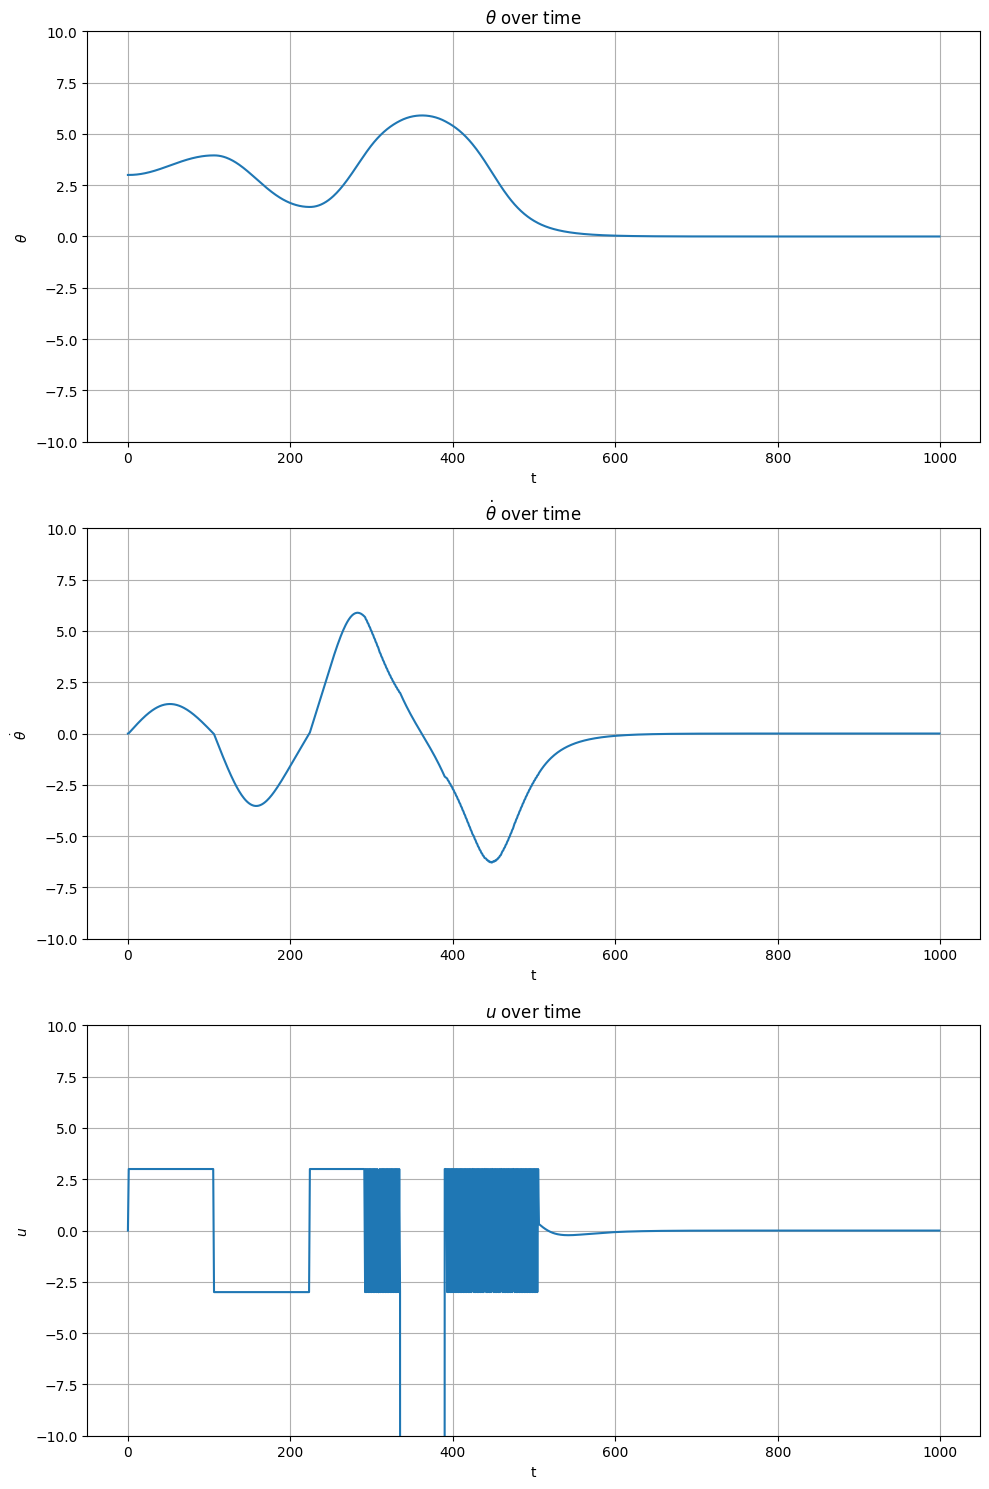

In [67]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))
axes = axes.flatten()

x_traj = np.array(x_traj)
u_traj = np.array(u_traj)
thetas = x_traj[:, 0]
dthetas = x_traj[:, 1]

for name, data, ax in zip([r"$\theta$", r"$\dot{\theta}$", r"$u$"], [thetas, dthetas, u_traj], axes):
    ax.plot(data)
    ax.set_title(f"{name} over time")
    ax.set_xlabel("t")
    ax.set_ylabel(name)
    ax.grid(True)
    ax.set_ylim(-10, 10)

plt.tight_layout()
plt.show()


In [63]:
import mediapy

mediapy.show_video(frames, fps=25)

This browser does not support the video tag.


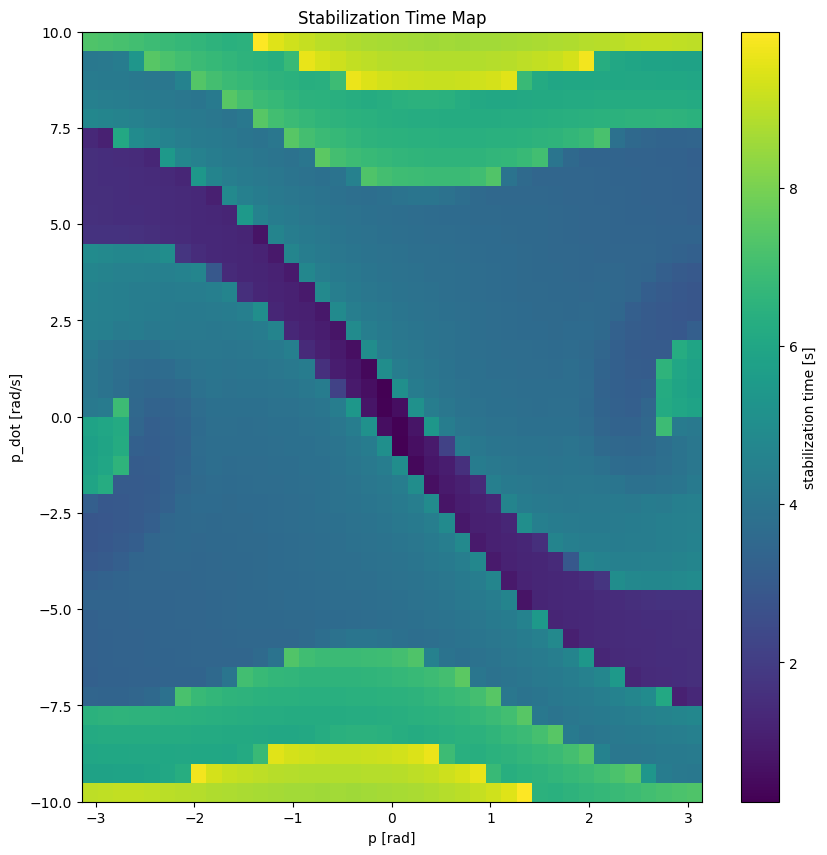

In [69]:
def wrap_to_pi(x: np.ndarray) -> np.ndarray:
    return (x + np.pi) % (2 * np.pi) - np.pi


def get_stabilization_time(
    x_traj: np.ndarray,
    p_eps: float = 0.1,
    p_dot_eps: float = 0.1,
    dt: float = 0.01,
) -> float:
    p_wrapped = wrap_to_pi(np.asarray(x_traj)[:, 0])
    p_dot = np.asarray(x_traj)[:, 1]

    is_stable = (np.abs(p_wrapped) < p_eps) & (np.abs(p_dot) < p_dot_eps)

    if not np.any(is_stable):
        return float("inf")

    stable_until_end = np.flip(np.cumprod(is_stable[::-1].astype(bool)))

    if not np.any(stable_until_end):
        return float("inf")

    first_stable_idx = np.argmax(stable_until_end)
    return first_stable_idx * dt


def get_stabilization_time_map(
    control_fn: Callable[[np.ndarray, float], float],
    num_trials: int = 20,
    max_steps: int = 1500,
):
    p_range = np.linspace(-np.pi, np.pi, num_trials)
    p_dot_range = np.linspace(-10, 10, num_trials)

    times = np.zeros((num_trials, num_trials))

    for i, p_dot in enumerate(p_dot_range):
        for j, p in enumerate(p_range):
            init_x = np.array([p, p_dot])

            simulator = InvertedPendulumSimulator(l=l, m=m, g=g)
            x_traj = []
            obs = simulator.reset(init_x)

            for _ in range(max_steps):
                x_traj.append(obs.copy())
                u = control_fn(obs.copy(), simulator.tau_max)
                obs = simulator.step(u)

            x_traj.append(obs.copy())

            times[i, j] = get_stabilization_time(np.array(x_traj), dt=simulator.dt)

    plt.figure(figsize=(10, 10))
    extent = [p_range.min(), p_range.max(), p_dot_range.min(), p_dot_range.max()]
    plt.imshow(times, cmap="viridis", origin="lower", aspect="auto", extent=extent)
    plt.colorbar(label="stabilization time [s]")
    plt.xlabel("p [rad]")
    plt.ylabel("p_dot [rad/s]")
    plt.title("Stabilization Time Map")
    plt.show()


control_fn_for_map = partial(
    thresholded_energy_control_fn,
    m=m,
    g=g,
    l=l,
    kp=kp,
    kd=kd,
    threshold=threshold,
)


get_stabilization_time_map(control_fn_for_map, num_trials=40)

Energy-based контроль сходится всегда быстрее, чем эвристические контроллеры